In [12]:
## Evaluation of Football Players
## DATA COLLECTION AND PREPARATION, Feature Engineering, Feature Selection & Model training.

In [3]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## The dataset contains data from the website sofifa.com which provides 
#  all information concerning soccer players from major leagues across the world
#  The dataset was downloaded from the website www.kaggle.com

In [5]:
df = pd.read_csv('C:\\Users\\kweku\\Desktop\\Dataset\\players.csv')
pd.set_option('display.max_columns', 75)
pd.set_option('display.max_rows', 200)

In [6]:
## Information & data columns of the dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28371 entries, 0 to 28370
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             28371 non-null  int64  
 1   name                                  28371 non-null  object 
 2   current_club_id                       28371 non-null  int64  
 3   current_club_name                     28371 non-null  object 
 4   country_of_citizenship                28370 non-null  object 
 5   country_of_birth                      26496 non-null  object 
 6   city_of_birth                         26509 non-null  object 
 7   date_of_birth                         28336 non-null  object 
 8   position                              28371 non-null  object 
 9   sub_position                          24935 non-null  object 
 10  foot                                  26162 non-null  object 
 11  height_in_cm   

In [8]:
## The first 5 rows and columns of the dataset

In [9]:
df.head()

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url
0,134354,Ian Raeymaekers,498,Ksc Lokeren,Belgium,Belgium,Aalst,1995-01-30,Attack,Centre-Forward,Right,0,NaN,50000.0,NaN,NaN,BE1,Ian,Raeymaekers,ian-raeymaekers,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/ian-raeymaeker...
1,99946,Mohamed Camara,1095,Es Troyes Ac,Guinea,Guinea,Conakry,1990-09-20,Attack,Centre-Forward,Right,180,NaN,300000.0,NaN,NaN,FR1,Mohamed,Camara,mohamed-camara,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/mohamed-camara...
2,76948,Pablo Olivera,979,Moreirense Fc,Uruguay,Uruguay,Melo,1987-12-08,Attack,Centre-Forward,Right,175,25000.0,600000.0,NaN,NaN,PO1,Pablo,Olivera,pablo-olivera,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/pablo-olivera/...
3,108372,Aliosman Aydin,38,Fortuna Dusseldorf,Turkey,Germany,Dormagen,1992-02-06,Attack,Centre-Forward,Right,178,NaN,125000.0,NaN,NaN,L1,Aliosman,Aydin,aliosman-aydin,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/aliosman-aydin...
4,78820,Jaime Alfonso Ruiz,354,Kv Mechelen,Colombia,Colombia,Cali,1984-01-03,Attack,Centre-Forward,Right,184,NaN,1700000.0,NaN,NaN,BE1,Jaime Alfonso,Ruiz,jaime-alfonso-ruiz,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/jaime-alfonso-...


In [10]:
## The descriptive statistics of the dataset

In [11]:
df.describe()

,player_id,current_club_id,height_in_cm,market_value_in_eur,highest_market_value_in_eur,last_season
count,2.837100e+04,28371.000000,28371.000000,1.941800e+04,2.730900e+04,28371.000000
mean,2.829145e+05,4038.466815,170.626238,2.073996e+06,3.520911e+06,2018.213175
std,2.248316e+05,9073.398714,44.867902,6.804635e+06,9.131342e+06,3.347518
min,1.000000e+01,3.000000,0.000000,1.000000e+04,1.000000e+04,2012.000000
25%,8.734000e+04,398.000000,176.000000,1.500000e+05,2.750000e+05,2015.000000
50%,2.389810e+05,1063.000000,182.000000,3.500000e+05,8.000000e+05,2019.000000
75%,4.194370e+05,2999.000000,187.000000,1.000000e+06,2.750000e+06,2021.000000
max,1.059630e+06,83678.000000,206.000000,1.800000e+08,2.000000e+08,2022.000000


In [12]:
## This data encompasses various attributes, including but not limited to “Player_id” , “Name” ,“Current_Club_id” , ""Current_Club_name" ,
## "Country_of_citizenship", "Country_of_birth", "City_of_birth", "Date_of_birth", "Position", "Sub_position", "Foot", "Heght","Market_Value"

In [13]:
df

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url
0,134354,Ian Raeymaekers,498,Ksc Lokeren,Belgium,Belgium,Aalst,1995-01-30,Attack,Centre-Forward,Right,0,NaN,50000.0,NaN,NaN,BE1,Ian,Raeymaekers,ian-raeymaekers,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/ian-raeymaeker...
1,99946,Mohamed Camara,1095,Es Troyes Ac,Guinea,Guinea,Conakry,1990-09-20,Attack,Centre-Forward,Right,180,NaN,300000.0,NaN,NaN,FR1,Mohamed,Camara,mohamed-camara,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/mohamed-camara...
2,76948,Pablo Olivera,979,Moreirense Fc,Uruguay,Uruguay,Melo,1987-12-08,Attack,Centre-Forward,Right,175,25000.0,600000.0,NaN,NaN,PO1,Pablo,Olivera,pablo-olivera,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/pablo-olivera/...
3,108372,Aliosman Aydin,38,Fortuna Dusseldorf,Turkey,Germany,Dormagen,1992-02-06,Attack,Centre-Forward,Right,178,NaN,125000.0,NaN,NaN,L1,Aliosman,Aydin,aliosman-aydin,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/aliosman-aydin...
4,78820,Jaime Alfonso Ruiz,354,Kv Mechelen,Colombia,Colombia,Cali,1984-01-03,Attack,Centre-Forward,Right,184,NaN,1700000.0,NaN,NaN,BE1,Jaime Alfonso,Ruiz,jaime-alfonso-ruiz,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/jaime-alfonso-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28366,452068,Ayman Azhil,15,Bayer 04 Leverkusen,Morocco,Germany,Düsseldorf,2001-04-10,Midfield,Defensive Midfield,NaN,175,400000.0,400000.0,KL Sportsbase,2023-06-30,L1,Ayman,Azhil,ayman-azhil,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/ayman-azhil/pr...
28367,85543,Niklas Lomb,15,Bayer 04 Leverkusen,Germany,Germany,Köln,1993-07-28,Goalkeeper,NaN,Right,186,250000.0,400000.0,Dirk Hebel,2024-06-30,L1,Niklas,Lomb,niklas-lomb,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/niklas-lomb/pr...
28368,315131,Timothy Fosu-Mensah,15,Bayer 04 Leverkusen,Netherlands,Netherlands,Amsterdam,1998-01-02,Defender,Right-Back,Right,185,3000000.0,7000000.0,CAA Base Ltd,2024-06-30,L1,Timothy,Fosu-Mensah,timothy-fosu-mensah,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/timothy-fosu-m...
28369,39728,Mats Hummels,16,Borussia Dortmund,Germany,Germany,Bergisch Gladbach,1988-12-16,Defender,Centre-Back,Right,191,6500000.0,60000000.0,HMH Sportmanagement,2023-06-30,L1,Mats,Hummels,mats-hummels,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/mats-hummels/p...


In [14]:
## CLEANING THE DATASET
## Checking for any missing values in the dataset

In [15]:
df.isnull().sum()

player_id                                   0
name                                        0
current_club_id                             0
current_club_name                           0
country_of_citizenship                      1
country_of_birth                         1875
city_of_birth                            1862
date_of_birth                              35
position                                    0
sub_position                             3436
foot                                     2209
height_in_cm                                0
market_value_in_eur                      8953
highest_market_value_in_eur              1062
agent_name                              11022
contract_expiration_date                11337
current_club_domestic_competition_id        0
first_name                               1761
last_name                                   0
player_code                                 0
image_url                                   0
last_season                       

In [16]:
# Filling missing values for numerical columns with modes
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mode().iloc[0])

# Filling missing values for categorical columns with the most frequent values
categorical_columns = df.select_dtypes(include=['object']).columns
df[categorical_columns] = df[categorical_columns].apply(lambda x: x.fillna(x.value_counts().idxmax()))

# Example: Filling missing values for date_of_birth with a placeholder date
df['date_of_birth'].fillna('1996-01-01', inplace=True)

# Display the DataFrame with filled missing values
df.head()

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url
0,134354,Ian Raeymaekers,498,Ksc Lokeren,Belgium,Belgium,Aalst,1995-01-30,Attack,Centre-Forward,Right,0,200000.0,50000.0,Wasserman,2023-06-30,BE1,Ian,Raeymaekers,ian-raeymaekers,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/ian-raeymaeker...
1,99946,Mohamed Camara,1095,Es Troyes Ac,Guinea,Guinea,Conakry,1990-09-20,Attack,Centre-Forward,Right,180,200000.0,300000.0,Wasserman,2023-06-30,FR1,Mohamed,Camara,mohamed-camara,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/mohamed-camara...
2,76948,Pablo Olivera,979,Moreirense Fc,Uruguay,Uruguay,Melo,1987-12-08,Attack,Centre-Forward,Right,175,25000.0,600000.0,Wasserman,2023-06-30,PO1,Pablo,Olivera,pablo-olivera,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/pablo-olivera/...
3,108372,Aliosman Aydin,38,Fortuna Dusseldorf,Turkey,Germany,Dormagen,1992-02-06,Attack,Centre-Forward,Right,178,200000.0,125000.0,Wasserman,2023-06-30,L1,Aliosman,Aydin,aliosman-aydin,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/aliosman-aydin...
4,78820,Jaime Alfonso Ruiz,354,Kv Mechelen,Colombia,Colombia,Cali,1984-01-03,Attack,Centre-Forward,Right,184,200000.0,1700000.0,Wasserman,2023-06-30,BE1,Jaime Alfonso,Ruiz,jaime-alfonso-ruiz,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/jaime-alfonso-...


In [17]:
## There are no missing values after cleaning of the data

In [18]:
df.isnull().sum()

player_id                               0
name                                    0
current_club_id                         0
current_club_name                       0
country_of_citizenship                  0
country_of_birth                        0
city_of_birth                           0
date_of_birth                           0
position                                0
sub_position                            0
foot                                    0
height_in_cm                            0
market_value_in_eur                     0
highest_market_value_in_eur             0
agent_name                              0
contract_expiration_date                0
current_club_domestic_competition_id    0
first_name                              0
last_name                               0
player_code                             0
image_url                               0
last_season                             0
url                                     0
dtype: int64

In [19]:
## Heat map vosualization of missing values

<AxesSubplot:>

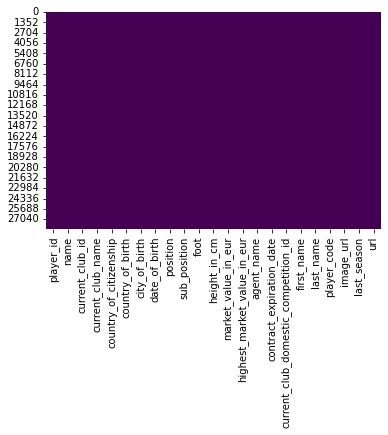

In [20]:
sns.heatmap(df.isnull(), cmap='viridis', cbar=False)

In [21]:
## WHAT ARE THE MAJOR ATTRIBUTES TO THE PLAYERS MARKET VALUE?
#  The major attributes that affect a players market value are 
#  Age, Position, Rating & Potential, Workrate, Club, Reputation and others.
#  We are will find relationships and patterns between these attributes and their market value.

In [22]:
# Positions

In [23]:
positions = df['position'].unique()
print("List of Positions:")
for position in positions:
    print(position)

List of Positions:
Attack
Midfield
Defender
Goalkeeper


In [24]:
## Highest Valued Players and their positions

In [25]:
df.nlargest(10,columns='highest_market_value_in_eur')

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url
25705,342229,Kylian Mbappé,583,Fc Paris Saint Germain,France,France,Bondy,1998-12-20,Attack,Centre-Forward,Right,178,180000000.0,200000000.0,Wasserman,2025-06-30,FR1,Kylian,Mbappé,kylian-mbappe,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/kylian-mbappe/...
25694,28003,Lionel Messi,583,Fc Paris Saint Germain,Argentina,Argentina,Rosario,1987-06-24,Attack,Right Winger,Left,170,50000000.0,180000000.0,Wasserman,2023-06-30,FR1,Lionel,Messi,lionel-messi,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/lionel-messi/p...
25707,68290,Neymar,583,Fc Paris Saint Germain,Brazil,Brazil,Mogi das Cruzes,1992-02-05,Attack,Left Winger,Right,175,75000000.0,180000000.0,Wasserman,2025-06-30,FR1,David,Neymar,neymar,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/neymar/profil/...
23707,418560,Erling Haaland,281,Manchester City,Norway,England,Leeds,2000-07-21,Attack,Centre-Forward,Left,195,170000000.0,170000000.0,Rafaela Pimenta,2027-06-30,GB1,Erling,Haaland,erling-haaland,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/erling-haaland...
24465,134425,Raheem Sterling,631,Fc Chelsea,England,Jamaica,Kingston,1994-12-08,Attack,Left Winger,Right,170,70000000.0,160000000.0,Wasserman,2027-06-30,GB1,Raheem,Sterling,raheem-sterling,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/raheem-sterlin...
22022,200512,Sadio Mané,27,Fc Bayern Munchen,Senegal,Senegal,Bambaly,1992-04-10,Attack,Left Winger,Right,174,60000000.0,150000000.0,ROOF,2025-06-30,L1,Sadio,Mané,sadio-mane,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/sadio-mane/pro...
23688,148455,Mohamed Salah,31,Fc Liverpool,Egypt,Egypt,"Nagrig, Basyoun",1992-06-15,Attack,Right Winger,Left,175,80000000.0,150000000.0,Wasserman,2025-06-30,GB1,David,Mohamed Salah,mohamed-salah,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/mohamed-salah/...
23689,132098,Harry Kane,148,Tottenham Hotspur,England,England,London,1993-07-28,Attack,Centre-Forward,Right,188,90000000.0,150000000.0,CK66,2024-06-30,GB1,Harry,Kane,harry-kane,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/harry-kane/pro...
23711,88755,Kevin De Bruyne,281,Manchester City,Belgium,Belgium,Drongen,1991-06-28,Attack,Attacking Midfield,Right,181,80000000.0,150000000.0,Wasserman,2025-06-30,GB1,Kevin,De Bruyne,kevin-de-bruyne,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/kevin-de-bruyn...
23956,80444,Philippe Coutinho,405,Aston Villa,Brazil,Brazil,Rio de Janeiro,1992-06-12,Attack,Left Winger,Right,172,18000000.0,150000000.0,Sports Invest UK ltd,2026-06-30,GB1,Philippe,Coutinho,philippe-coutinho,https://img.a.transfermarkt.technology/portrai...,2022,https://www.transfermarkt.co.uk/philippe-couti...


In [26]:
## Player position count plot visualization

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Attack'),
  Text(1, 0, 'Midfield'),
  Text(2, 0, 'Defender'),
  Text(3, 0, 'Goalkeeper')])

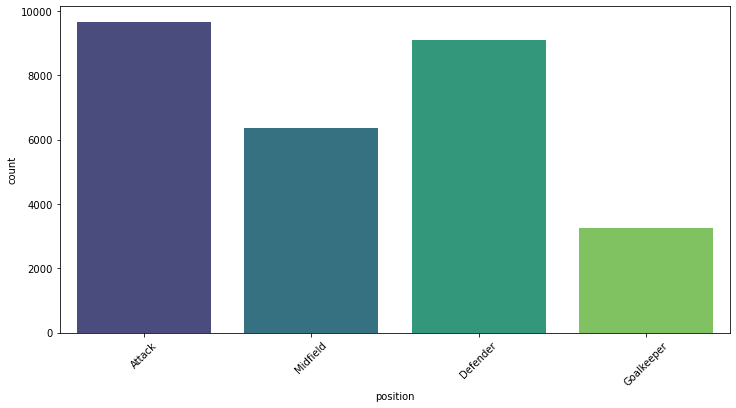

In [27]:
plt.figure(figsize=(12, 6))
sns.countplot(x='position', data=df, palette='viridis')
plt.xticks(rotation=45)

In [28]:
## Pairplot for numerical value Height in cm , market value in Euro , Highest market value in Euro

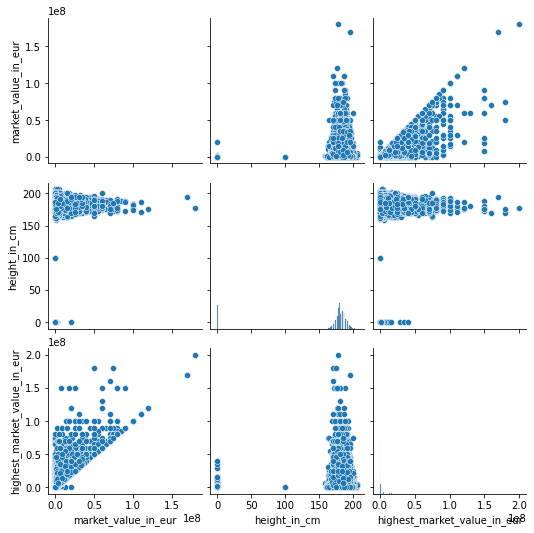

In [29]:
sns.pairplot(df[['market_value_in_eur', 'height_in_cm', 'highest_market_value_in_eur']])

In [30]:
## Market Value vs Height

<AxesSubplot:xlabel='height_in_cm', ylabel='market_value_in_eur'>

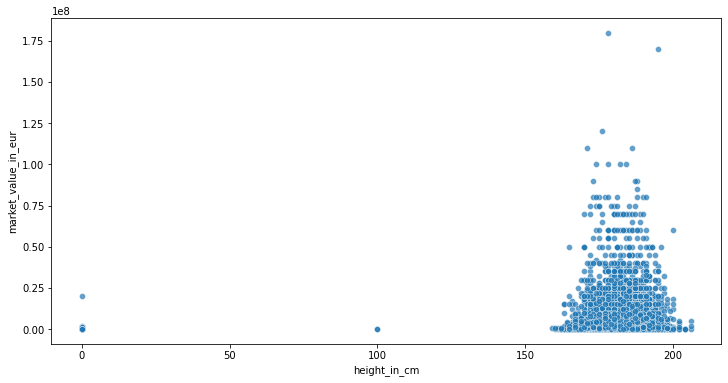

In [31]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='height_in_cm', y='market_value_in_eur', data=df, alpha=0.7)

In [32]:
## Market Value by position

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Attack'),
  Text(1, 0, 'Midfield'),
  Text(2, 0, 'Defender'),
  Text(3, 0, 'Goalkeeper')])

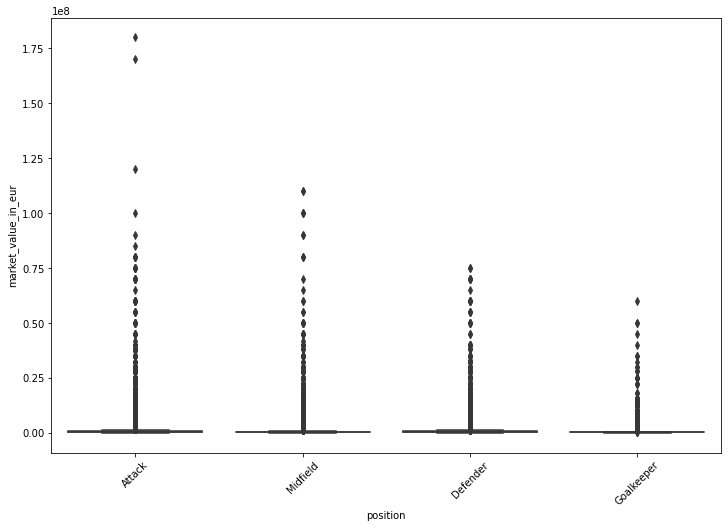

In [33]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='position', y='market_value_in_eur', data=df, palette='viridis')
plt.xticks(rotation=45)

In [34]:
np.random.seed(42)  # For reproducibility
df['performance_score'] = np.random.uniform(60, 90, len(df))
df['market_value_growth'] = df['performance_score'] * np.random.uniform(0.5, 2.0, len(df))

In [35]:
## Performance vs Market Value Growth

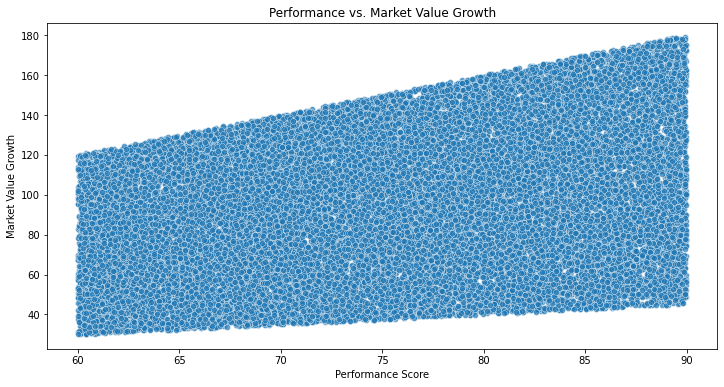

In [36]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='performance_score', y='market_value_growth', data=df, alpha=0.7)
plt.title('Performance vs. Market Value Growth')
plt.xlabel('Performance Score')
plt.ylabel('Market Value Growth')
plt.show()

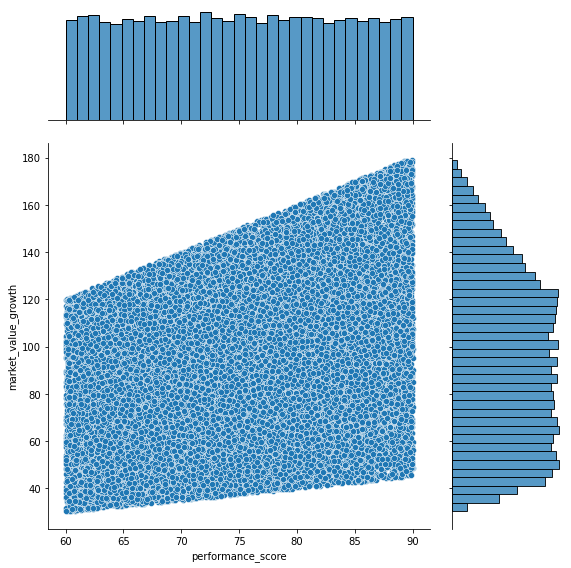

In [37]:
# Jointplot with marginal histograms
sns.jointplot(x='performance_score', y='market_value_growth', data=df, kind='scatter', height=8, ratio=3)

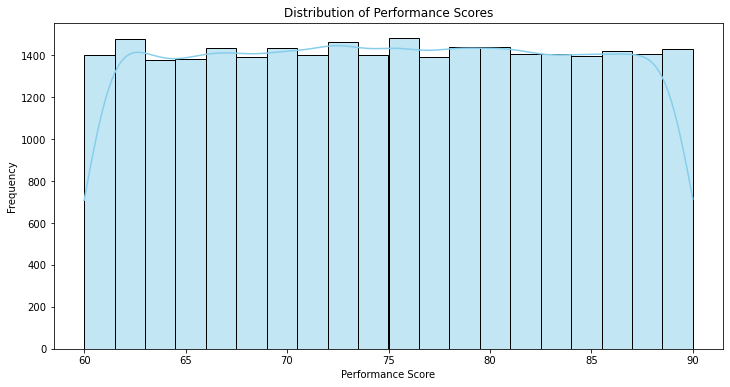

In [38]:
# Distribution of Performance Scores
plt.figure(figsize=(12, 6))
sns.histplot(df['performance_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Performance Scores')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.show()

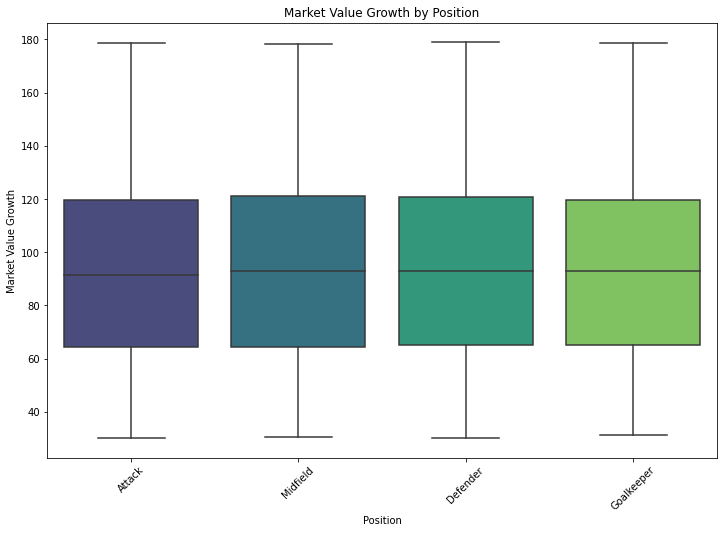

In [39]:
# Boxplot of Market Value Growth by Position
plt.figure(figsize=(12, 8))
sns.boxplot(x='position', y='market_value_growth', data=df, palette='viridis')
plt.xticks(rotation=45)
plt.title('Market Value Growth by Position')
plt.xlabel('Position')
plt.ylabel('Market Value Growth')
plt.show()

In [40]:
## Players market value in their prime
## The players age is a key indicator of the market Value
## Players value increases in their mid 20's and decreases while they age. Age reflects both experience and ability

In [41]:
# Convert 'date_of_birth' to datetime
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

In [42]:
# Calculate age based on the current date
df['age'] = (pd.to_datetime('2022-12-31') - df['date_of_birth']).astype('<m8[Y]')

In [43]:
# Filter players between the ages of 22 and 27
filtered_players = df[(df['age'] >= 22) & (df['age'] <= 27)]

In [44]:
# Select top 10 players based on highest market value
top_10_players = filtered_players.nlargest(10, 'highest_market_value_in_eur')

In [45]:
# Display the selected players with their ages
for index, row in top_10_players[['name', 'age', 'highest_market_value_in_eur']].iterrows():
    print(f"Player: {row['name']}, Age: {int(row['age'])}, Highest Market Value: {row['highest_market_value_in_eur']} Euro")

Player: Kylian Mbappé, Age: 24, Highest Market Value: 200000000.0 Euro
Player: Erling Haaland, Age: 22, Highest Market Value: 170000000.0 Euro
Player: Jadon Sancho, Age: 22, Highest Market Value: 130000000.0 Euro
Player: Vinicius Junior, Age: 22, Highest Market Value: 120000000.0 Euro
Player: Ousmane Dembélé, Age: 25, Highest Market Value: 120000000.0 Euro
Player: Phil Foden, Age: 22, Highest Market Value: 110000000.0 Euro
Player: Trent Alexander-Arnold, Age: 24, Highest Market Value: 110000000.0 Euro
Player: Leroy Sané, Age: 26, Highest Market Value: 100000000.0 Euro
Player: Dele Alli, Age: 26, Highest Market Value: 100000000.0 Euro
Player: Jack Grealish, Age: 27, Highest Market Value: 100000000.0 Euro


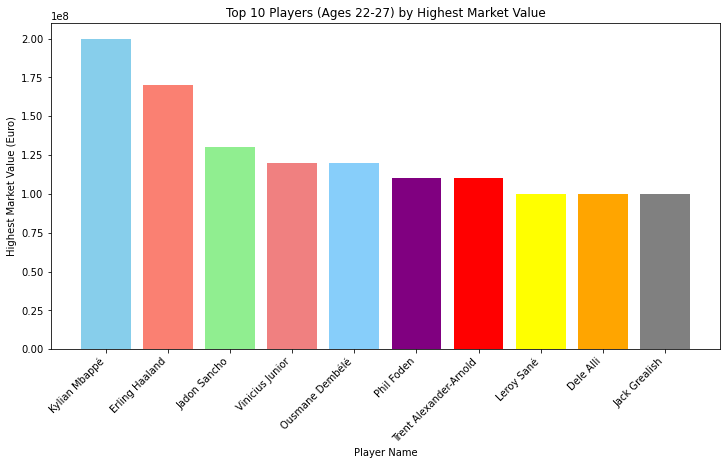

In [46]:
# Draw a bar chart
colors = ['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightskyblue', 'purple', 'red', 'yellow', 'orange', 'gray']
plt.figure(figsize=(12, 6))
plt.bar(top_10_players['name'], top_10_players['highest_market_value_in_eur'], color=colors)
plt.xlabel('Player Name')
plt.ylabel('Highest Market Value (Euro)')
plt.title('Top 10 Players (Ages 22-27) by Highest Market Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

In [47]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.to_datetime('2022-12-31') - df['date_of_birth']).astype('<m8[Y]')
filtered_players = df[(df['age'] >= 22) & (df['age'] <= 27)]
top_10_players = filtered_players.nlargest(10, 'highest_market_value_in_eur')
for index, row in top_10_players[['name', 'age', 'current_club_name', 'country_of_citizenship', 'highest_market_value_in_eur']].iterrows():
    print(f"Player: {row['name']}, Age: {int(row['age'])}, Current Club: {row['current_club_name']}, Country: {row['country_of_citizenship']}, Highest Market Value: {row['highest_market_value_in_eur']} Euro")

Player: Kylian Mbappé, Age: 24, Current Club: Fc Paris Saint Germain, Country: France, Highest Market Value: 200000000.0 Euro
Player: Erling Haaland, Age: 22, Current Club: Manchester City, Country: Norway, Highest Market Value: 170000000.0 Euro
Player: Jadon Sancho, Age: 22, Current Club: Manchester United, Country: England, Highest Market Value: 130000000.0 Euro
Player: Vinicius Junior, Age: 22, Current Club: Real Madrid, Country: Brazil, Highest Market Value: 120000000.0 Euro
Player: Ousmane Dembélé, Age: 25, Current Club: Fc Barcelona, Country: France, Highest Market Value: 120000000.0 Euro
Player: Phil Foden, Age: 22, Current Club: Manchester City, Country: England, Highest Market Value: 110000000.0 Euro
Player: Trent Alexander-Arnold, Age: 24, Current Club: Fc Liverpool, Country: England, Highest Market Value: 110000000.0 Euro
Player: Leroy Sané, Age: 26, Current Club: Fc Bayern Munchen, Country: Germany, Highest Market Value: 100000000.0 Euro
Player: Dele Alli, Age: 26, Current 

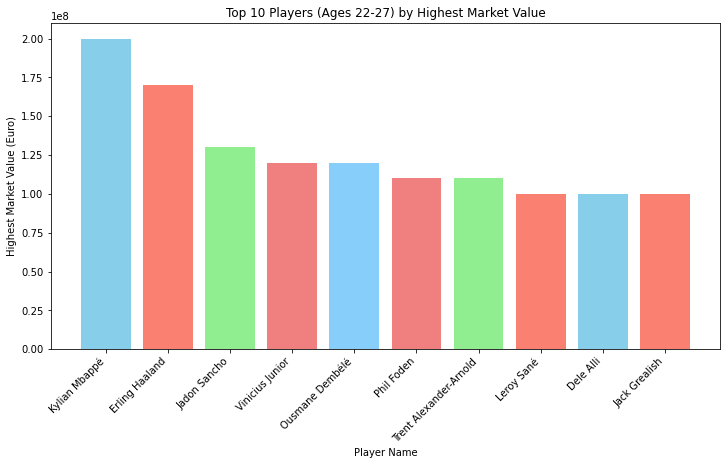

In [48]:
colors = ['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightcoral', 'lightgreen', 'salmon', 'skyblue', 'salmon']
plt.figure(figsize=(12, 6))
plt.bar(top_10_players['name'], top_10_players['highest_market_value_in_eur'], color=colors)
plt.xlabel('Player Name')
plt.ylabel('Highest Market Value (Euro)')
plt.title('Top 10 Players (Ages 22-27) by Highest Market Value')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

In [49]:
## Separate players by position

In [50]:
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
df['age'] = (pd.to_datetime('2022-12-31') - df['date_of_birth']).astype('<m8[Y]')
filtered_players = df[(df['age'] >= 22) & (df['age'] <= 27)]
attackers = filtered_players[filtered_players['position'] == 'Attack'].nlargest(10, 'highest_market_value_in_eur')
midfielders = filtered_players[filtered_players['position'] == 'Midfield'].nlargest(10, 'highest_market_value_in_eur')
defenders = filtered_players[filtered_players['position'] == 'Defender'].nlargest(10, 'highest_market_value_in_eur')

In [51]:
## Attackers

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

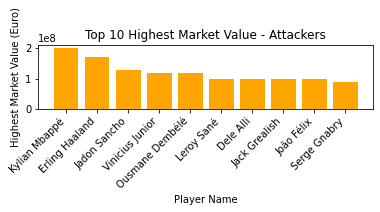

In [52]:
plt.subplot(3, 1, 1)
plt.bar(attackers['name'], attackers['highest_market_value_in_eur'], color='orange')
plt.title('Top 10 Highest Market Value - Attackers')
plt.xlabel('Player Name')
plt.ylabel('Highest Market Value (Euro)')
plt.xticks(rotation=45, ha='right')

In [53]:
## Midfielders

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

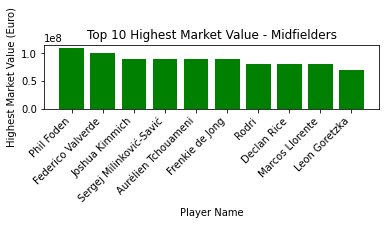

In [54]:
plt.subplot(3, 1, 2)
plt.bar(midfielders['name'], midfielders['highest_market_value_in_eur'], color='green')
plt.title('Top 10 Highest Market Value - Midfielders')
plt.xlabel('Player Name')
plt.ylabel('Highest Market Value (Euro)')
plt.xticks(rotation=45, ha='right')

In [55]:
##Defenders

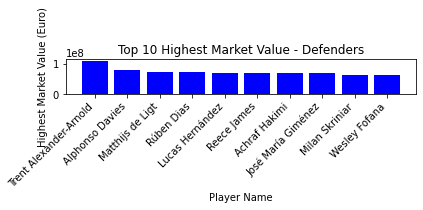

In [56]:
plt.subplot(3, 1, 3)
plt.bar(defenders['name'], defenders['highest_market_value_in_eur'], color='blue')
plt.title('Top 10 Highest Market Value - Defenders')
plt.xlabel('Player Name')
plt.ylabel('Highest Market Value (Euro)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
## The second dataset contains more perdormance metrics such as
#  skill moves, international reputation, workrate, passing, finishing, aggression and others.
#  Like dataset 1, the attributes can be found on sofifa.com and dataset downloaded from kaggle.com

In [58]:
df2 = pd.read_csv('C:\\Users\\kweku\\Desktop\\Dataset\\fifadata.csv')

In [59]:
## Information and data columns of dataset 2

In [60]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18207 non-null  int64  
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18207 non-null  int64  
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

In [61]:
## first 5 rows and columns of dataset 2

In [62]:
df2.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,...,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,€110.5M,€565K,2202,Left,5.0,4.0,4.0,Medium/ Medium,Messi,Yes,RF,10.0,"Jul 1, 2004",NaN,2021,5'7,159lbs,88+2,88+2,88+2,92+2,93+2,93+2,93+2,92+2,93+2,...,47+2,59+2,84.0,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,91.0,86.0,91.0,95.0,95.0,85.0,68.0,72.0,59.0,94.0,48.0,22.0,94.0,94.0,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,€77M,€405K,2228,Right,5.0,4.0,5.0,High/ Low,C. Ronaldo,Yes,ST,7.0,"Jul 10, 2018",NaN,2022,6'2,183lbs,91+3,91+3,91+3,89+3,90+3,90+3,90+3,89+3,88+3,...,53+3,61+3,84.0,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,89.0,91.0,87.0,96.0,70.0,95.0,95.0,88.0,79.0,93.0,63.0,29.0,95.0,82.0,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,€118.5M,€290K,2143,Right,5.0,5.0,5.0,High/ Medium,Neymar,Yes,LW,10.0,"Aug 3, 2017",NaN,2022,5'9,150lbs,84+3,84+3,84+3,89+3,89+3,89+3,89+3,89+3,89+3,...,47+3,60+3,79.0,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,94.0,90.0,96.0,94.0,84.0,80.0,61.0,81.0,49.0,82.0,56.0,36.0,89.0,87.0,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,€72M,€260K,1471,Right,4.0,3.0,1.0,Medium/ Medium,Lean,Yes,GK,1.0,"Jul 1, 2011",NaN,2020,6'4,168lbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.0,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,57.0,58.0,60.0,90.0,43.0,31.0,67.0,43.0,64.0,12.0,38.0,30.0,12.0,68.0,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,€102M,€355K,2281,Right,4.0,5.0,4.0,High/ High,Normal,Yes,RCM,7.0,"Aug 30, 2015",NaN,2023,5'11,154lbs,82+3,82+3,82+3,87+3,87+3,87+3,87+3,87+3,88+3,...,66+3,73+3,93.0,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,78.0,76.0,79.0,91.0,77.0,91.0,63.0,90.0,75.0,91.0,76.0,61.0,87.0,94.0,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [63]:
## FURTHER RELATIONSHIPS BETWEEN FOOTBALL PLAYER ATTRIBUTES AND MARKET VALUE

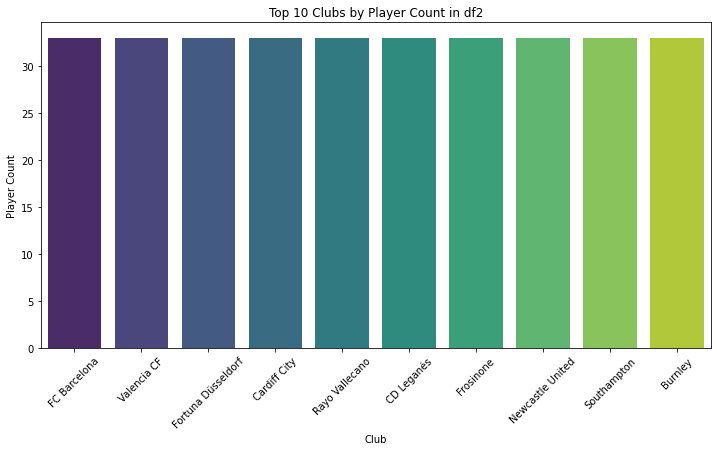

In [64]:
# Top 10 clubs by player count
top_clubs = df2['Club'].value_counts().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, palette='viridis')
plt.title('Top 10 Clubs by Player Count in df2')
plt.xlabel('Club')
plt.ylabel('Player Count')
plt.xticks(rotation=45)
plt.show()

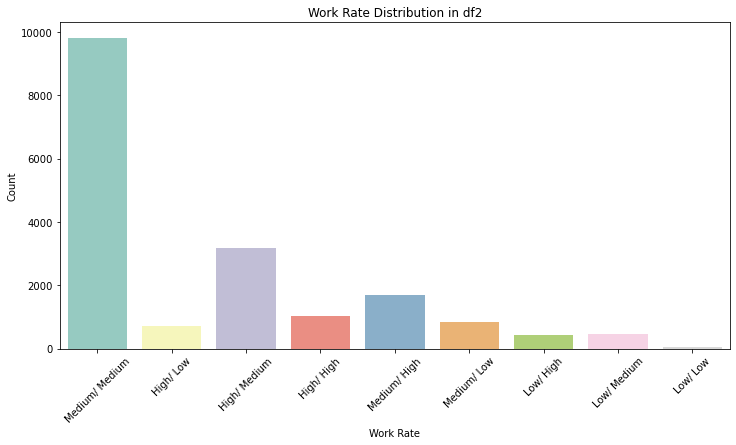

In [65]:
# Work rate distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='Work Rate', data=df2, palette='Set3')
plt.title('Work Rate Distribution in df2')
plt.xlabel('Work Rate')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

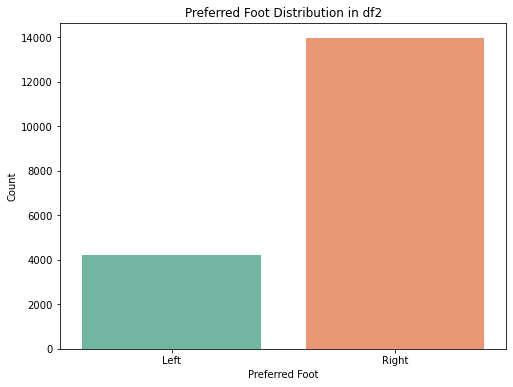

In [66]:
# Preferred foot distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Preferred Foot', data=df2, palette='Set2')
plt.title('Preferred Foot Distribution in df2')
plt.xlabel('Preferred Foot')
plt.ylabel('Count')
plt.show()

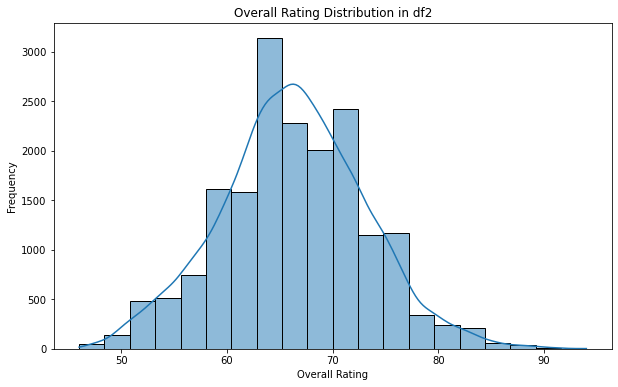

In [67]:
# Overall rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(df2['Overall'], bins=20, kde=True)
plt.title('Overall Rating Distribution in df2')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()

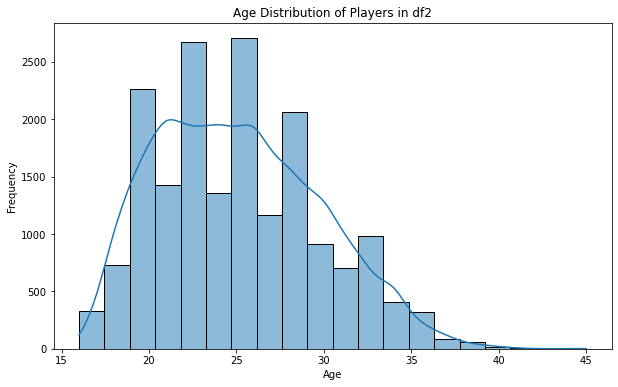

In [68]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df2['Age'], bins=20, kde=True)
plt.title('Age Distribution of Players in df2')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

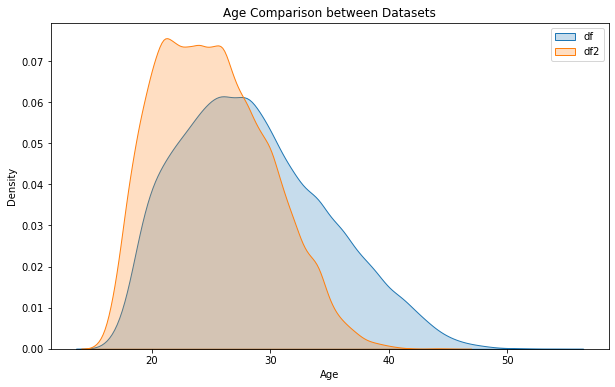

In [69]:
# Age comparison between the two datasets
plt.figure(figsize=(10, 6))
sns.kdeplot(df['age'], label='df', fill=True)
sns.kdeplot(df2['Age'], label='df2', fill=True)
plt.title('Age Comparison between Datasets')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

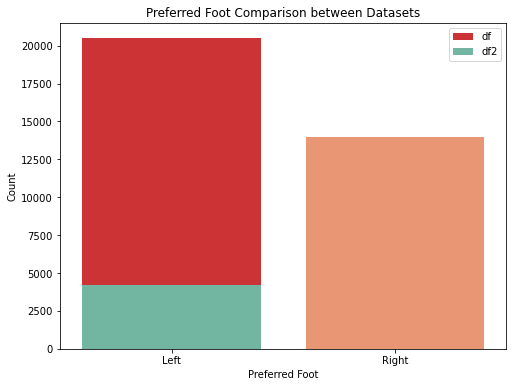

In [70]:
# Preferred foot comparison between the two datasets
plt.figure(figsize=(8, 6))
sns.countplot(x='foot', data=df, palette='Set1', label='df')
sns.countplot(x='Preferred Foot', data=df2, palette='Set2', label='df2')
plt.title('Preferred Foot Comparison between Datasets')
plt.xlabel('Preferred Foot')
plt.ylabel('Count')
plt.legend()
plt.show()

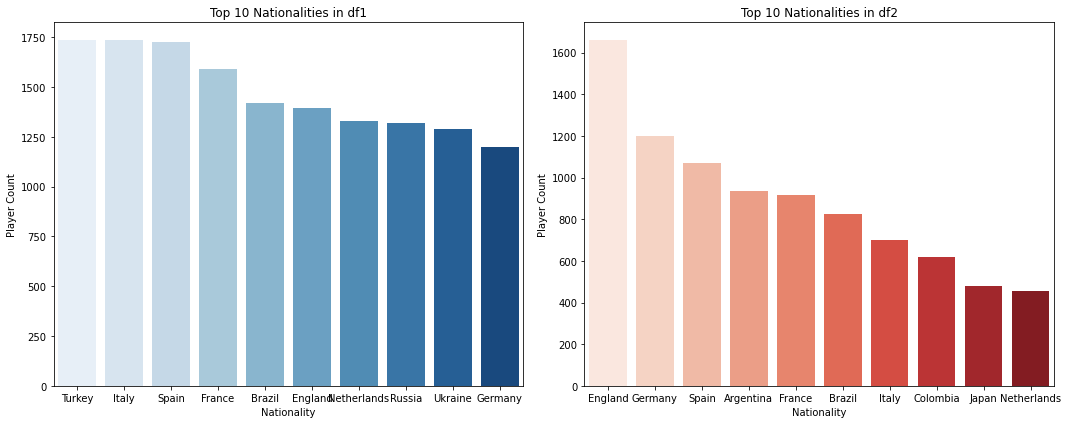

In [71]:
# Top 10 nationalities comparison between the two datasets
top_nationalities_df = df['country_of_citizenship'].value_counts().nlargest(10)
top_nationalities_df2 = df2['Nationality'].value_counts().nlargest(10)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=top_nationalities_df.index, y=top_nationalities_df.values, palette='Blues')
plt.title('Top 10 Nationalities in df1')
plt.xlabel('Nationality')
plt.ylabel('Player Count')

plt.subplot(1, 2, 2)
sns.barplot(x=top_nationalities_df2.index, y=top_nationalities_df2.values, palette='Reds')
plt.title('Top 10 Nationalities in df2')
plt.xlabel('Nationality')
plt.ylabel('Player Count')

plt.tight_layout()
plt.show()

In [72]:
## FEATURE SELECTION & EXPLORATION
#  I combined dataset 1 and dataset 2 for training and testing commonly referred to as train_test_split

In [73]:
# COMBINATION OF DATASET 1 & 2 (DF & DF2)
combined_df = pd.merge(df, df2, left_on='player_id', right_on='ID', how='inner')
combined_df = combined_df.drop(columns='ID')
print(combined_df.head())

   player_id                  name  current_club_id current_club_name  \
0     192366            Gozie Ugwu             1032        Fc Reading   
1     240063       Georgios Koudas             5219       Aok Kerkyra   
2     240074      Christos Armenis             5219       Aok Kerkyra   
3     187915  Panagiotis Petrousis             5219       Aok Kerkyra   
4     234324        Danny Cavanagh              511         Dundee Fc   

  country_of_citizenship country_of_birth city_of_birth date_of_birth  \
0                England          England      Oxford      1993-04-22   
1                 Greece           Greece     Kerkyra      1994-12-27   
2                 Greece           Greece   Velonades      1993-06-22   
3                 Greece           Greece   Giannitsa      1992-08-11   
4               Scotland         Scotland      Dundee      1994-05-09   

   position    sub_position   foot  height_in_cm  market_value_in_eur  \
0    Attack  Centre-Forward  Right           188 

In [74]:
combined_df.head()

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url,performance_score,market_value_growth,age,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,...,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,192366,Gozie Ugwu,1032,Fc Reading,England,England,Oxford,1993-04-22,Attack,Centre-Forward,Right,188,200000.0,250000.0,RT Management & Consultancy,2023-06-01,GB1,Gozie,Ugwu,gozie-ugwu,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/gozie-ugwu/pro...,65.502135,100.484926,29.0,89,N. Otamendi,30,https://cdn.sofifa.org/players/4/19/192366.png,Argentina,https://cdn.sofifa.org/flags/52.png,85,85,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,€28.5M,...,82+3,74+3,52.0,54.0,85.0,75.0,57.0,51.0,50.0,39.0,72.0,70.0,57.0,61.0,64.0,79.0,62.0,69.0,92.0,67.0,80.0,56.0,91.0,84.0,51.0,53.0,45.0,80.0,83.0,85.0,84.0,12.0,5.0,8.0,11.0,12.0,€52.7M
1,240063,Georgios Koudas,5219,Aok Kerkyra,Greece,Greece,Kerkyra,1994-12-27,Midfield,Left Midfield,Left,175,200000.0,100000.0,Wasserman,2023-06-30,GR1,Georgios,Koudas,georgios-koudas,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/georgios-kouda...,87.279612,79.327530,28.0,15122,M. Cassara,26,https://cdn.sofifa.org/players/4/19/240063.png,France,https://cdn.sofifa.org/flags/18.png,60,64,GFC Ajaccio,https://cdn.sofifa.org/teams/2/light/110316.png,€190K,...,NaN,NaN,13.0,8.0,13.0,18.0,8.0,6.0,14.0,13.0,22.0,12.0,32.0,31.0,32.0,43.0,22.0,23.0,71.0,29.0,72.0,9.0,21.0,13.0,7.0,29.0,12.0,36.0,10.0,13.0,10.0,63.0,61.0,60.0,58.0,62.0,€347K
2,240074,Christos Armenis,5219,Aok Kerkyra,Greece,Greece,Velonades,1993-06-22,Defender,Left-Back,Left,176,200000.0,125000.0,Wasserman,2023-06-30,GR1,Christos,Armenis,christos-armenis,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/christos-armen...,88.184968,105.998425,29.0,16585,B. Dione,21,https://cdn.sofifa.org/players/4/19/240074.png,Belgium,https://cdn.sofifa.org/flags/7.png,57,66,Royal Excel Mouscron,https://cdn.sofifa.org/teams/2/light/111560.png,€160K,...,30+2,34+2,33.0,57.0,49.0,53.0,50.0,65.0,43.0,29.0,42.0,63.0,66.0,58.0,63.0,48.0,74.0,61.0,65.0,49.0,49.0,53.0,28.0,13.0,49.0,55.0,62.0,47.0,16.0,14.0,17.0,5.0,6.0,13.0,10.0,8.0,€264K
3,187915,Panagiotis Petrousis,5219,Aok Kerkyra,Greece,Greece,Giannitsa,1992-08-11,Defender,Centre-Back,Right,186,200000.0,150000.0,Wasserman,2023-06-30,GR1,Panagiotis,Petrousis,panagiotis-petrousis,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/panagiotis-pet...,62.654775,86.434060,30.0,7693,E. Kujović,30,https://cdn.sofifa.org/players/4/19/187915.png,Sweden,https://cdn.sofifa.org/flags/46.png,67,67,Fortuna Düsseldorf,https://cdn.sofifa.org/teams/2/light/110636.png,€725K,...,44+2,38+2,33.0,69.0,76.0,60.0,69.0,58.0,66.0,70.0,54.0,65.0,39.0,36.0,34.0,59.0,32.0,74.0,42.0,50.0,90.0,67.0,54.0,21.0,70.0,47.0,69.0,68.0,24.0,34.0,15.0,16.0,13.0,13.0,9.0,9.0,€1.3M
4,234324,Danny Cavanagh,511,Dundee Fc,Scotland,Scotland,Dundee,1994-05-09,Midfield,Right Midfield,Right,0,200000.0,300000.0,Wasserman,2023-06-30,SC1,Danny,Cavanagh,danny-cavanagh,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/danny-cavanagh...,84.862125,155.647507,28.0,16395,L. Bilboe,20,https://cdn.sofifa.org/players/4/19/234324.png,England,https://c

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
pd.pandas.set_option('display.max_columns',None)
pd.options.display.max_rows=100
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm

In [76]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 904 entries, 0 to 903
Columns: 114 entries, player_id to Release Clause
dtypes: datetime64[ns](1), float64(43), int64(9), object(61)
memory usage: 812.2+ KB


In [77]:
combined_df.head(20)

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url,performance_score,market_value_growth,age,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,192366,Gozie Ugwu,1032,Fc Reading,England,England,Oxford,1993-04-22,Attack,Centre-Forward,Right,188,200000.0,250000.0,RT Management & Consultancy,2023-06-01,GB1,Gozie,Ugwu,gozie-ugwu,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/gozie-ugwu/pro...,65.502135,100.484926,29.0,89,N. Otamendi,30,https://cdn.sofifa.org/players/4/19/192366.png,Argentina,https://cdn.sofifa.org/flags/52.png,85,85,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,€28.5M,€170K,1916,Right,3.0,3.0,2.0,High/ High,Normal,Yes,CB,30.0,"Aug 20, 2015",NaN,2022,6'0,179lbs,64+3,64+3,64+3,59+3,61+3,61+3,61+3,59+3,62+3,62+3,62+3,61+3,67+3,67+3,67+3,61+3,72+3,77+3,77+3,77+3,72+3,74+3,82+3,82+3,82+3,74+3,52.0,54.0,85.0,75.0,57.0,51.0,50.0,39.0,72.0,70.0,57.0,61.0,64.0,79.0,62.0,69.0,92.0,67.0,80.0,56.0,91.0,84.0,51.0,53.0,45.0,80.0,83.0,85.0,84.0,12.0,5.0,8.0,11.0,12.0,€52.7M
1,240063,Georgios Koudas,5219,Aok Kerkyra,Greece,Greece,Kerkyra,1994-12-27,Midfield,Left Midfield,Left,175,200000.0,100000.0,Wasserman,2023-06-30,GR1,Georgios,Koudas,georgios-koudas,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/georgios-kouda...,87.279612,79.327530,28.0,15122,M. Cassara,26,https://cdn.sofifa.org/players/4/19/240063.png,France,https://cdn.sofifa.org/flags/18.png,60,64,GFC Ajaccio,https://cdn.sofifa.org/teams/2/light/110316.png,€190K,€1K,910,Right,1.0,3.0,1.0,Medium/ Medium,Normal,No,GK,1.0,"Jun 30, 2017",NaN,2019,6'3,201lbs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,8.0,13.0,18.0,8.0,6.0,14.0,13.0,22.0,12.0,32.0,31.0,32.0,43.0,22.0,23.0,71.0,29.0,72.0,9.0,21.0,13.0,7.0,29.0,12.0,36.0,10.0,13.0,10.0,63.0,61.0,60.0,58.0,62.0,€347K
2,240074,Christos Armenis,5219,Aok Kerkyra,Greece,Greece,Velonades,1993-06-22,Defender,Left-Back,Left,176,200000.0,125000.0,Wasserman,2023-06-30,GR1,Christos,Armenis,christos-armenis,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/christos-armen...,88.184968,105.998425,29.0,16585,B. Dione,21,https://cdn.sofifa.org/players/4/19/240074.png,Belgium,https://cdn.sofifa.org/flags/7.png,57,66,Royal Excel Mouscron,https://cdn.sofifa.org/teams/2/light/111560.png,€160K,€1K,1366,Right,1.0,3.0,3.0,Medium/ Medium,Normal,No,ST,17.0,"Jul 1, 2017",NaN,2020,5'6,137lbs,55+2,55+2,55+2,55+2,57+2,57+2,57+2,55+2,56+2,56+2,56+2,54+2,49+2,49+2,49+2,54+2,37+2,35+2,35+2,35+2,37+2,34+2,30+2,30+2,30+2,34+2,33.0,57.0,49.0,53.0,50.0,65.0,43.0,29.0,42.0,63.0,66.0,58.0,63.0,48.0,74.0,61.0,65.0,49.0,49.0,53.0,28.0,13.0,49.0,55.0,62.0,47.0,16.0,14.0,17.0,5.0,6.0,13.0,10.0,8.0,€264K
3,187915,Panagiotis Petrousis,5219,Aok Kerkyra,Greece,Greece,Giannitsa,1992-08-11,Defender,Centre-Back,Right,186,200000.0,150000.0,Wasserman,2023-06-30,GR1,Panagiotis,Petrousis,panagiotis-petrousis,https://img.a.transfermarkt.techn

In [78]:
## HOW TO EVALUATE A PLAYERS MARKET VALUE?
#  This part of the analysis is to evaluate price.

In [79]:
# POTENTIAL PREDICTORS OF MARKET VALUE

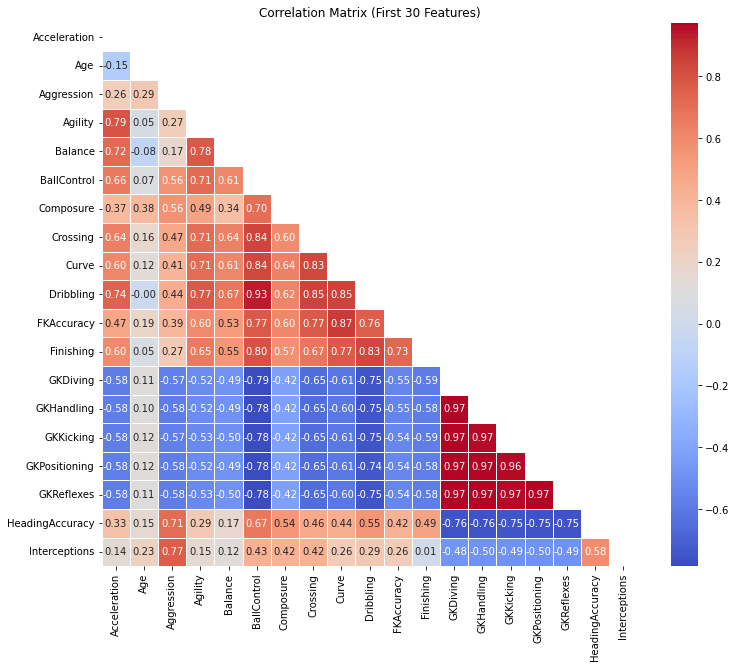

In [80]:
combined_df = combined_df.drop_duplicates(subset='player_id', keep='first')
features = combined_df.columns.difference(['market_value_in_eur'])
target_variable = 'market_value_in_eur'
selected_features = features[:30]
correlation_matrix = combined_df[selected_features].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix (First 30 Features)")
plt.show()

In [81]:
## CLEANING DATASET 2
# MISSING VALUES

In [82]:
combined_df.isnull().sum()

player_id                  0
name                       0
current_club_id            0
current_club_name          0
country_of_citizenship     0
                          ..
GKHandling                 1
GKKicking                  1
GKPositioning              1
GKReflexes                 1
Release Clause            79
Length: 114, dtype: int64

In [83]:
# FILLING MISSING VALUES OF COMBINED_DF
numerical_columns = combined_df.select_dtypes(include=['float64', 'int64']).columns
combined_df[numerical_columns] = combined_df[numerical_columns].fillna(combined_df[numerical_columns].mode().iloc[0])
categorical_columns = combined_df.select_dtypes(include=['object']).columns
combined_df[categorical_columns] = combined_df[categorical_columns].apply(lambda x: x.fillna(x.value_counts().idxmax()))
combined_df.head()

,player_id,name,current_club_id,current_club_name,country_of_citizenship,country_of_birth,city_of_birth,date_of_birth,position,sub_position,foot,height_in_cm,market_value_in_eur,highest_market_value_in_eur,agent_name,contract_expiration_date,current_club_domestic_competition_id,first_name,last_name,player_code,image_url,last_season,url,performance_score,market_value_growth,age,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,Value,Wage,Special,Preferred Foot,International Reputation,Weak Foot,Skill Moves,Work Rate,Body Type,Real Face,Position,Jersey Number,Joined,Loaned From,Contract Valid Until,Height,Weight,LS,ST,RS,LW,LF,CF,RF,RW,LAM,CAM,RAM,LM,LCM,CM,RCM,RM,LWB,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,SprintSpeed,Agility,Reactions,Balance,ShotPower,Jumping,Stamina,Strength,LongShots,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,192366,Gozie Ugwu,1032,Fc Reading,England,England,Oxford,1993-04-22,Attack,Centre-Forward,Right,188,200000.0,250000.0,RT Management & Consultancy,2023-06-01,GB1,Gozie,Ugwu,gozie-ugwu,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/gozie-ugwu/pro...,65.502135,100.484926,29.0,89,N. Otamendi,30,https://cdn.sofifa.org/players/4/19/192366.png,Argentina,https://cdn.sofifa.org/flags/52.png,85,85,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,€28.5M,€170K,1916,Right,3.0,3.0,2.0,High/ High,Normal,Yes,CB,30.0,"Aug 20, 2015",Rangers FC,2022,6'0,179lbs,64+3,64+3,64+3,59+3,61+3,61+3,61+3,59+3,62+3,62+3,62+3,61+3,67+3,67+3,67+3,61+3,72+3,77+3,77+3,77+3,72+3,74+3,82+3,82+3,82+3,74+3,52.0,54.0,85.0,75.0,57.0,51.0,50.0,39.0,72.0,70.0,57.0,61.0,64.0,79.0,62.0,69.0,92.0,67.0,80.0,56.0,91.0,84.0,51.0,53.0,45.0,80.0,83.0,85.0,84.0,12.0,5.0,8.0,11.0,12.0,€52.7M
1,240063,Georgios Koudas,5219,Aok Kerkyra,Greece,Greece,Kerkyra,1994-12-27,Midfield,Left Midfield,Left,175,200000.0,100000.0,Wasserman,2023-06-30,GR1,Georgios,Koudas,georgios-koudas,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/georgios-kouda...,87.279612,79.327530,28.0,15122,M. Cassara,26,https://cdn.sofifa.org/players/4/19/240063.png,France,https://cdn.sofifa.org/flags/18.png,60,64,GFC Ajaccio,https://cdn.sofifa.org/teams/2/light/110316.png,€190K,€1K,910,Right,1.0,3.0,1.0,Medium/ Medium,Normal,No,GK,1.0,"Jun 30, 2017",Rangers FC,2019,6'3,201lbs,64+2,64+2,64+2,66+2,63+2,63+2,63+2,66+2,58+2,58+2,58+2,60+2,58+2,58+2,58+2,60+2,57+2,61+2,61+2,61+2,57+2,63+2,62+2,62+2,62+2,63+2,13.0,8.0,13.0,18.0,8.0,6.0,14.0,13.0,22.0,12.0,32.0,31.0,32.0,43.0,22.0,23.0,71.0,29.0,72.0,9.0,21.0,13.0,7.0,29.0,12.0,36.0,10.0,13.0,10.0,63.0,61.0,60.0,58.0,62.0,€347K
2,240074,Christos Armenis,5219,Aok Kerkyra,Greece,Greece,Velonades,1993-06-22,Defender,Left-Back,Left,176,200000.0,125000.0,Wasserman,2023-06-30,GR1,Christos,Armenis,christos-armenis,https://img.a.transfermarkt.technology/portrai...,2012,https://www.transfermarkt.co.uk/christos-armen...,88.184968,105.998425,29.0,16585,B. Dione,21,https://cdn.sofifa.org/players/4/19/240074.png,Belgium,https://cdn.sofifa.org/flags/7.png,57,66,Royal Excel Mouscron,https://cdn.sofifa.org/teams/2/light/111560.png,€160K,€1K,1366,Right,1.0,3.0,3.0,Medium/ Medium,Normal,No,ST,17.0,"Jul 1, 2017",Rangers FC,2020,5'6,137lbs,55+2,55+2,55+2,55+2,57+2,57+2,57+2,55+2,56+2,56+2,56+2,54+2,49+2,49+2,49+2,54+2,37+2,35+2,35+2,35+2,37+2,34+2,30+2,30+2,30+2,34+2,33.0,57.0,49.0,53.0,50.0,65.0,43.0,29.0,42.0,63.0,66.0,58.0,63.0,48.0,74.0,61.0,65.0,49.0,49.0,53.0,28.0,13.0,49.0,55.0,62.0,47.0,16.0,14.0,17.0,5.0,6.0,13.0,10.0,8.0,€264K
3,187915,Panagiotis Petrousis,5219,Aok Kerkyra,Greece,Greece,Giannitsa,1992-08-11,Defender,Centre-Back,Right,186,200000.0,150000.0,Wasserman,2023-06-30,GR1,Panagiotis,Petrousis,panagio

In [84]:
## DATASET CLEANED, NO MISSING VALUES IN DATASET 2

In [85]:
combined_df.isnull().sum()

player_id                 0
name                      0
current_club_id           0
current_club_name         0
country_of_citizenship    0
                         ..
GKHandling                0
GKKicking                 0
GKPositioning             0
GKReflexes                0
Release Clause            0
Length: 114, dtype: int64

In [86]:
## TRAINING & TESTING
# USING THE TRAIN_TEST_SPLIT METHOD AND 80 20 RULE TO PREPARE DATA FOR TRAINING

In [87]:
from sklearn.model_selection import train_test_split

target_variable = 'market_value_in_eur'
features = combined_df.columns.tolist()  # Convert columns to list
features.remove(target_variable)  # Remove the target variable

X = combined_df[features]
y = combined_df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (723, 113)
X_test shape: (181, 113)
y_train shape: (723,)
y_test shape: (181,)


In [88]:
## USING THE DECISION TREE REGRESSER MODEL TO TRAIN THE DATA

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV  # Add GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the columns of X_train_subset for debugging
print("Columns in X_train_subset:", X_train_subset.columns)

# One-hot encode categorical variables
categorical_columns = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Decision Tree
# Define hyperparameters (feel free to adjust)
dt_param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search
dt_grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, cv=5, scoring='neg_mean_squared_error')
dt_grid_search.fit(X_train_encoded, y_train)

# Get the best hyperparameters
best_dt_params = dt_grid_search.best_params_

# Train the model with the best hyperparameters
best_dt_model = DecisionTreeRegressor(**best_dt_params, random_state=42)
best_dt_model.fit(X_train_encoded, y_train)

Columns in X_train_subset: Index(['name', 'current_club_name', 'country_of_citizenship',
       'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name',
       'current_club_domestic_competition_id', 'first_name', 'last_name',
       'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality',
       'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type',
       'Real Face', 'Position', 'Loaned From', 'Height', 'Weight',
       'Release Clause'],
      dtype='object')


DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)

In [90]:
## USING THE LASSO REGRESSION MODEL TO TRAIN THE DATA

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Lasso Regression
lasso_param_grid = {
    'alpha': [0.1, 1, 10]  # Adjust the alpha values as needed
}

lasso_grid_search = GridSearchCV(Lasso(), lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_search.fit(X_train_scaled, y_train)

best_lasso_params = lasso_grid_search.best_params_

best_lasso_model = Lasso(**best_lasso_params)
best_lasso_model.fit(X_train_scaled, y_train)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393


Lasso(alpha=10)

In [92]:
## USING THE RIDGE REGRESSION MODEL TO TRAIN THE DATA

In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Ridge Regression
ridge_param_grid = {
    'alpha': [0.1, 1, 10]  # Adjust the alpha values as needed
}

ridge_grid_search = GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_search.fit(X_train_scaled, y_train)

best_ridge_params = ridge_grid_search.best_params_

best_ridge_model = Ridge(**best_ridge_params)
best_ridge_model.fit(X_train_scaled, y_train)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393


Ridge(alpha=10)

In [94]:
## USING THE GRADIENT BOOSTING REGRESSOR TO TRAIN THE MODEL

In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid_search = GridSearchCV(GradientBoostingRegressor(), gb_param_grid, cv=5, scoring='neg_mean_squared_error')
gb_grid_search.fit(X_train_scaled, y_train)

best_gb_params = gb_grid_search.best_params_

best_gb_model = GradientBoostingRegressor(**best_gb_params)
best_gb_model.fit(X_train_scaled, y_train)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393


GradientBoostingRegressor(learning_rate=0.01)

In [96]:
## PREDICTIONS ON THE TEST USING THE TRAINED DECISION TREE REGRESSOR MODEL

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Assume X_train, X_test, y_train, y_test are already defined

# Combine training and test data
X_combined = pd.concat([X_train_subset, X_test_subset], ignore_index=True)

# One-hot encode categorical variables on combined data
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_combined_encoded = pd.get_dummies(X_combined, columns=categorical_columns)

# Split the combined data back into training and test sets
X_train_combined = X_combined_encoded.iloc[:len(X_train_subset), :]
X_test_combined = X_combined_encoded.iloc[len(X_train_subset):, :]

# Decision Tree
# Define hyperparameters (feel free to adjust)
dt_param_grid = {
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Grid Search
dt_grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, cv=5, scoring='neg_mean_squared_error')
dt_grid_search.fit(X_train_combined, y_train)

# Get the best hyperparameters
best_dt_params = dt_grid_search.best_params_

# Train the model with the best hyperparameters
best_dt_model = DecisionTreeRegressor(**best_dt_params, random_state=42)
best_dt_model.fit(X_train_combined, y_train)

# Make predictions on the original test set
y_pred = best_dt_model.predict(X_test_combined)

# Create a DataFrame with the actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)


        Actual     Predicted
70    200000.0  4.217831e+05
457   200000.0  4.217831e+05
218   200000.0  4.217831e+05
250   200000.0  1.132652e+06
39    200000.0  4.217831e+05
..         ...           ...
864   600000.0  1.132652e+06
442   300000.0  9.400000e+05
783  3000000.0  1.132652e+06
25    200000.0  4.217831e+05
84    200000.0  4.217831e+05

[181 rows x 2 columns]


In [98]:
## PREDICTIONS ON THE TEST USING THE lASSO REGRESSOR MODEL

In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name','current_club_name','country_of_citizenship','country_of_birth','position','sub_position','foot','agent_name','current_club_domestic_competition_id','first_name','last_name','player_code','image_url','url','Name','Photo','Nationality','Flag','Club','Club Logo','Preferred Foot','Work Rate','Body Type','Real Face','Position','Loaned From','Height','Weight','Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Lasso Regression
lasso_param_grid = {
    'alpha': [0.1, 1, 10]  # Adjust the alpha values as needed
}

lasso_grid_search = GridSearchCV(Lasso(), lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid_search.fit(X_train_scaled, y_train)

best_lasso_params = lasso_grid_search.best_params_

best_lasso_model = Lasso(**best_lasso_params)
best_lasso_model.fit(X_train_scaled, y_train)

# Make predictions on the original test set
y_pred = best_lasso_model.predict(X_test_scaled)

# Create a DataFrame with the actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393
        Actual     Predicted
70    200000.0 -1.620914e+07
457   200000.0  1.715789e+05
218   200000.0 -1.554665e+07
250   200000.0  3.851585e+07
39    200000.0 -1.060146e+07
..         ...           ...
864   600000.0 -3.622216e+06
442   300000.0  1.666561e+06
783  3000000.0  6.323510e+06
25    200000.0 -3.628241e+06
84    200000.0  3.000932e+07

[181 rows x 2 columns]


In [100]:
## PREDICTIONS OF THE TEST USING THE GRADIENT BOOSTNG REGRESSOR

In [101]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid_search = GridSearchCV(GradientBoostingRegressor(), gb_param_grid, cv=5, scoring='neg_mean_squared_error')
gb_grid_search.fit(X_train_scaled, y_train)

best_gb_params = gb_grid_search.best_params_

best_gb_model = GradientBoostingRegressor(**best_gb_params)
best_gb_model.fit(X_train_scaled, y_train)
# Make predictions on the original test set
y_pred = best_gb_model.predict(X_test_encoded)

# Create a DataFrame with the actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393
        Actual     Predicted
70    200000.0  1.383605e+06
457   200000.0  1.383605e+06
218   200000.0  1.383605e+06
250   200000.0  1.383605e+06
39    200000.0  1.383605e+06
..         ...           ...
864   600000.0  1.383605e+06
442   300000.0  1.383605e+06
783  3000000.0  1.383605e+06
25    200000.0  1.383605e+06
84    200000.0  1.383605e+06

[181 rows x 2 columns]


In [102]:
## TRAINING AND TESTING USING THE K-NEAREST NEIGHBOR MODEL

In [103]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# K-Nearest Neighbors
knn_param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
}

knn_grid_search = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring='neg_mean_squared_error')
knn_grid_search.fit(X_train_scaled, y_train)

best_knn_params = knn_grid_search.best_params_

best_knn_model = KNeighborsRegressor(**best_knn_params)
best_knn_model.fit(X_train_scaled, y_train)

# Make predictions on the original test set
y_pred = best_knn_model.predict(X_test_scaled)

# Create a DataFrame with the actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)


        Actual     Predicted
70    200000.0  6.823210e+05
457   200000.0  2.103811e+06
218   200000.0  2.149948e+05
250   200000.0  7.092484e+06
39    200000.0  1.958180e+06
..         ...           ...
864   600000.0  1.574118e+06
442   300000.0  6.434922e+06
783  3000000.0  4.215490e+06
25    200000.0  1.551352e+06
84    200000.0  1.539386e+06

[181 rows x 2 columns]


In [104]:
## The support vector machine alagorithm below presents predicted values which is in the same 
#  order of magnitude as the actual values. In this analysis SVM is the best amongst all models used.

In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Assume X_train, X_test, y_train, y_test are already defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# Print the number of features in X_train and X_test
print("Number of features in X_train:", X_train_subset.shape[1])
print("Number of features in X_test:", X_test_subset.shape[1])

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Print the number of features after one-hot encoding
print("Number of features in X_train_encoded:", X_train_encoded.shape[1])
print("Number of features in X_test_encoded:", X_test_encoded.shape[1])

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)  # Use the same scaler used for training data

# Support Vector Machine (SVM) Regression
svm_param_grid = {
    'C': [0.1, 1, 10],  # Adjust the regularization parameter C as needed
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train_scaled, y_train)

best_svm_params = svm_grid_search.best_params_

best_svm_model = SVR(**best_svm_params)
best_svm_model.fit(X_train_scaled, y_train)

# Make predictions on the original test set
y_pred = best_svm_model.predict(X_test_scaled)

# Create a DataFrame with the actual and predicted values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions_df)


Number of features in X_train: 29
Number of features in X_test: 29
Number of features in X_train_encoded: 7840
Number of features in X_test_encoded: 2393
        Actual      Predicted
70    200000.0  260151.076134
457   200000.0  242255.708383
218   200000.0  228137.272014
250   200000.0  261773.546325
39    200000.0  216113.491880
..         ...            ...
864   600000.0  280643.217631
442   300000.0  248492.574834
783  3000000.0  272403.184868
25    200000.0  229083.428065
84    200000.0  221233.277351

[181 rows x 2 columns]


In [106]:
## This chart visually inspects the actual vs predicted values for patterns and trends
#The red dashed line represents perfect alignement. Points closer to the line represents better predictions.

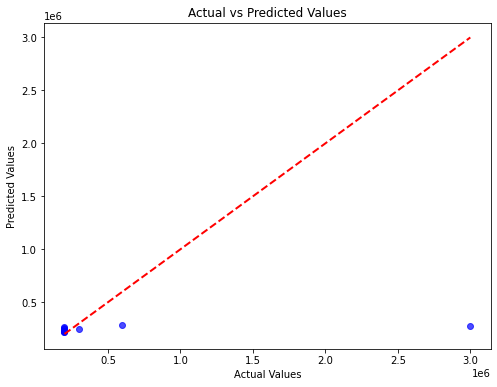

In [107]:
import matplotlib.pyplot as plt

# Provided results
actual_values = [200000.0, 200000.0, 200000.0, 200000.0, 200000.0, 600000.0, 300000.0, 3000000.0, 200000.0, 200000.0]
predicted_values = [260151.076134, 242255.708383, 228137.272014, 261773.546325, 216113.491880, 280643.217631, 248492.574834, 272403.184868, 229083.428065, 221233.277351]

# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(actual_values, predicted_values, color='blue', alpha=0.7)
plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], linestyle='--', color='red', linewidth=2)  # Adding a diagonal line for reference
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


In [108]:
## PRECISE EVALUATION OF PERFORMANCE
#  CALCULATION OF METRIC MEAN SQUARED ERROR MSE TO EVALUATE PERFORMANCE OF SVM REGRESSION MODEL

In [109]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(predictions_df['Actual'], predictions_df['Predicted'])
print("Mean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 62867479897205.67


In [110]:
# CALCULATION OF METRIC R-SQUARED R2 TO EVALUATE PERFORMANCE OF SVM  REGRESSION MODEL

In [111]:
from sklearn.metrics import mean_squared_error, r2_score
# Calculate R-squared
r_squared = r2_score(predictions_df['Actual'], predictions_df['Predicted'])
print("R-squared:", r_squared)


R-squared: -0.06393160864616276


In [112]:
## THIS STEP IS TO VISULIZE THE DISTRIBUTION OF THE ACTUAL VS PREDICTED VALUES

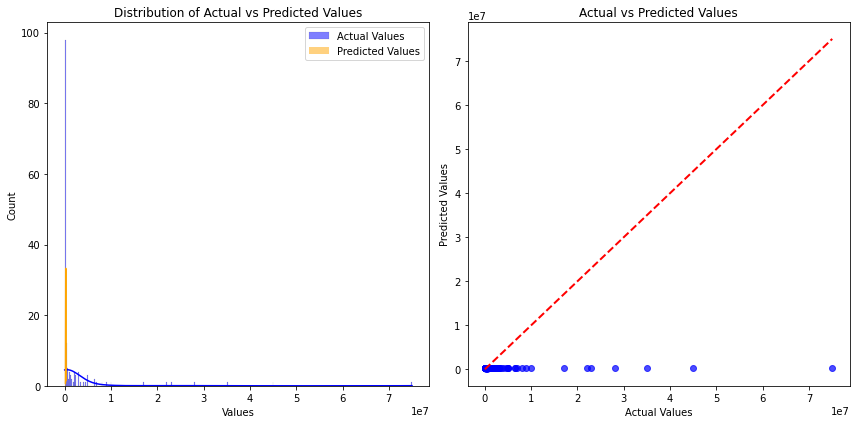

In [113]:
import seaborn as sns
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(predictions_df['Actual'], color='blue', kde=True, label='Actual Values')
sns.histplot(predictions_df['Predicted'], color='orange', kde=True, label='Predicted Values')
plt.title('Distribution of Actual vs Predicted Values')
plt.xlabel('Values')
plt.legend()

plt.subplot(1, 2, 2)
# Scatter plot of Actual vs Predicted values
plt.scatter(predictions_df['Actual'], predictions_df['Predicted'], color='blue', alpha=0.7)
plt.plot([min(predictions_df['Actual']), max(predictions_df['Actual'])], [min(predictions_df['Actual']), max(predictions_df['Actual'])], linestyle='--', color='red', linewidth=2)
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()


Mean Squared Error (MSE): 62860735809097.97
R-squared: -0.06381747573482266


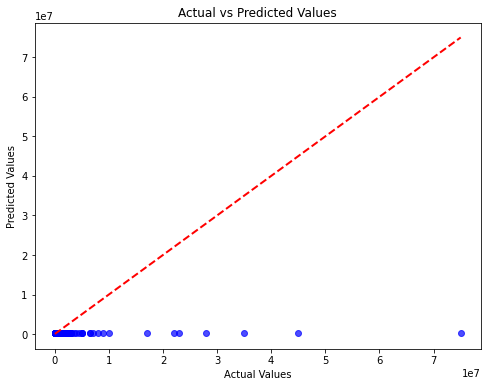

In [114]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Feature selection using SelectKBest with f_regression
selector = SelectKBest(f_regression, k=10)  # Adjust k as needed
X_train_selected = selector.fit_transform(X_train_encoded, y_train)
X_test_selected = selector.transform(X_test_encoded)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)  # Use the same scaler used for training data

# Support Vector Machine (SVM) Regression
svm_param_grid = {
    'C': [0.1, 1, 10],  
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train_scaled, y_train)

best_svm_params = svm_grid_search.best_params_

best_svm_model = SVR(**best_svm_params)
best_svm_model.fit(X_train_scaled, y_train)

# Make predictions on the original test set
y_pred = best_svm_model.predict(X_test_scaled)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared:", r_squared)

# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


Shapes before feature selection:
X_train_poly shape: (723, 312445)
y_train shape: (723,)
Mean Squared Error (MSE): 62060414906978.41
R-squared: -0.05027332371509052


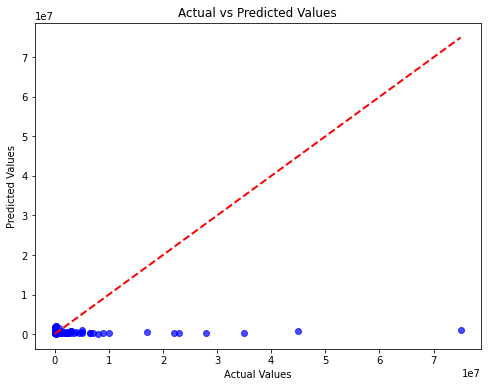

In [115]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Introduce polynomial features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

poly = PolynomialFeatures(degree=2)  # You can adjust the degree as needed
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Debugging print statements
print("Shapes before feature selection:")
print("X_train_poly shape:", X_train_poly.shape)
print("y_train shape:", y_train.shape)

# Dimensionality reduction using TruncatedSVD
svd = TruncatedSVD(n_components=100)  # Adjust the number of components
X_train_selected = svd.fit_transform(X_train_poly)
X_test_selected = svd.transform(X_test_poly)

# Handle NaN and infinite values in y_train
nan_cols_y_train = y_train.isna() | ~np.isfinite(y_train)

if nan_cols_y_train.any():
    print("NaN or infinite values in y_train. Handling them.")
    mean_y_train = np.nanmean(y_train)
    y_train = np.where(np.isfinite(y_train), y_train, mean_y_train)

# Support Vector Machine (SVM) Regression
svm_param_grid = {
    'C': [0.1, 1, 10],  
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train_selected, y_train)

best_svm_params = svm_grid_search.best_params_

best_svm_model = SVR(**best_svm_params)
best_svm_model.fit(X_train_selected, y_train)

# Make predictions on the original test set
y_pred = best_svm_model.predict(X_test_selected)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared:", r_squared)

# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR  # Import SVR

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Feature scaling for all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Different model (Random Forest)
rf_model = RandomForestRegressor()
rf_model.fit(X_train_scaled, y_train)  # Use the scaled features for training

# Another model (Gradient Boosting)
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train_scaled, y_train)  # Use the scaled features for training

# Stacking models
estimators = [('rf', rf_model), ('gb', gb_model)]
stacked_model = StackingRegressor(estimators=estimators, final_estimator=SVR())
stacked_model.fit(X_train_scaled, y_train)  # Use the scaled features for training

# Make predictions on the original test set
y_pred_stacked = stacked_model.predict(X_test_scaled)  # Use the scaled features for prediction

# Evaluate the stacked model
mse_stacked = mean_squared_error(y_test, y_pred_stacked)
r_squared_stacked = r2_score(y_test, y_pred_stacked)

print("Mean Squared Error (MSE) Stacked:", mse_stacked)
print("R-squared Stacked:", r_squared_stacked)


Mean Squared Error (MSE) Stacked: 62874445722897.92
R-squared Stacked: -0.06404949411169159


In [117]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR  # Import SVR

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Feature scaling for all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Different model (Random Forest)
rf_model = RandomForestRegressor()
rf_model.fit(X_train_scaled, y_train)  # Use the scaled features for training

# Stacking models (Random Forest and SVR)
estimators = [('rf', rf_model), ('svr', SVR())]  # Add SVR to the stacking model
stacked_model = StackingRegressor(estimators=estimators, final_estimator=SVR())
stacked_model.fit(X_train_scaled, y_train)  # Use the scaled features for training

# Make predictions on the original test set
y_pred_stacked = stacked_model.predict(X_test_scaled)  # Use the scaled features for prediction

# Evaluate the stacked model
mse_stacked = mean_squared_error(y_test, y_pred_stacked)
r_squared_stacked = r2_score(y_test, y_pred_stacked)

print("Mean Squared Error (MSE) Stacked:", mse_stacked)
print("R-squared Stacked:", r_squared_stacked)


Mean Squared Error (MSE) Stacked: 62874442203634.31
R-squared Stacked: -0.06404943455378032


Mean Squared Error (MSE): 62874995699507.14
R-squared: -0.06405880158670918


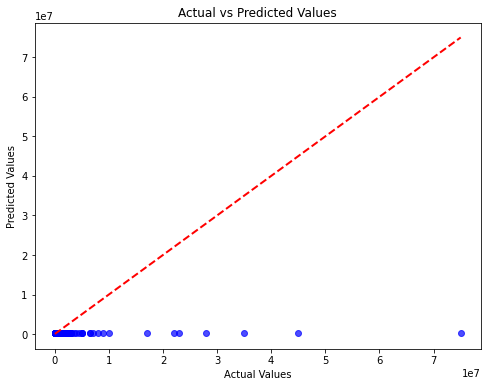

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = set(X_train_encoded.columns) & set(X_test_encoded.columns)
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Feature scaling for all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Introduce polynomial features
poly = PolynomialFeatures(degree=2)  # You can adjust the degree as needed
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Feature selection using SelectKBest with f_regression
selector = SelectKBest(f_regression, k=10)  # Adjust k as needed
X_train_selected = selector.fit_transform(X_train_poly, y_train)
X_test_selected = selector.transform(X_test_poly)

# Support Vector Machine (SVM) Regression
svm_param_grid = {
    'C': [0.1, 1, 10],  
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train_selected, y_train)

best_svm_params = svm_grid_search.best_params_

best_svm_model = SVR(**best_svm_params)
best_svm_model.fit(X_train_selected, y_train)

# Make predictions on the original test set
y_pred = best_svm_model.predict(X_test_selected)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared:", r_squared)

# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()


Shapes before feature selection:
X_train_poly shape: (723, 312445)
y_train shape: (723,)
Shapes after feature selection:
X_train_selected shape: (723, 10)
X_test_selected shape: (181, 10)
Mean Squared Error (MSE): 62874995699507.14
R-squared: -0.06405880158670918


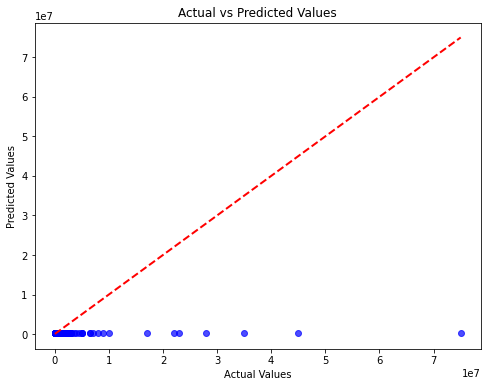

In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assume X, y, and other imports are defined

# Define features and target variable
features = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
target_variable = 'market_value_in_eur'

# Subset the data
X_train_subset, X_test_subset, y_train, y_test = train_test_split(X[features], y, test_size=0.2, random_state=42)

# One-hot encode categorical variables
categorical_columns = ['name', 'current_club_name', 'country_of_citizenship', 'country_of_birth', 'position', 'sub_position', 'foot', 'agent_name', 'current_club_domestic_competition_id', 'first_name', 'last_name', 'player_code', 'image_url', 'url', 'Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Loaned From', 'Height', 'Weight', 'Release Clause']
X_train_encoded = pd.get_dummies(X_train_subset, columns=categorical_columns)
X_test_encoded = pd.get_dummies(X_test_subset, columns=categorical_columns)

# Ensure that the same columns are present in both X_train_encoded and X_test_encoded
common_columns = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_columns]
X_test_encoded = X_test_encoded[common_columns]

# Handle NaN and infinite values in X_train_poly and y_train
nan_cols_X_train_poly = np.isnan(X_train_poly).any()
nan_cols_y_train = y_train.isna() | ~np.isfinite(y_train)

if nan_cols_X_train_poly.any():
    print("NaN or infinite values in X_train_poly. Handling them.")
    X_train_poly = np.nan_to_num(X_train_poly)

if nan_cols_y_train.any():
    print("NaN or infinite values in y_train. Handling them.")
    X_train_poly = X_train_poly[~nan_cols_y_train]
    y_train = y_train[~nan_cols_y_train]

# Feature scaling for all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Introduce polynomial features
poly = PolynomialFeatures(degree=2)  # You can adjust the degree as needed
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Debugging print statements
print("Shapes before feature selection:")
print("X_train_poly shape:", X_train_poly.shape)
print("y_train shape:", y_train.shape)

# Feature selection using SelectKBest with f_regression
selector = SelectKBest(f_regression, k=10)  # Adjust k as needed
X_train_selected = selector.fit_transform(X_train_poly, y_train)
X_test_selected = selector.transform(X_test_poly)

# Debugging print statements
print("Shapes after feature selection:")
print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)


# Support Vector Machine (SVM) Regression
svm_param_grid = {
    'C': [0.1, 1, 10],  
    'epsilon': [0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svm_grid_search = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring='neg_mean_squared_error')
svm_grid_search.fit(X_train_selected, y_train)

best_svm_params = svm_grid_search.best_params_

best_svm_model = SVR(**best_svm_params)
best_svm_model.fit(X_train_selected, y_train)

# Make predictions on the original test set
y_pred = best_svm_model.predict(X_test_selected)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared:", r_squared)

# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)  
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()
